[2026-03-06 Fiddler](https://thefiddler.substack.com/p/can-you-shovel-the-snow)
====================

Fiddler
-------
The lot can be divided into six equilateral triangles, where the vertices of a
triangle are two adjacent Team Vertex points and the Team Centroid point.

As the figure shows, one third of each triangle is closest to the Team Centroid
point, so Team Centroid shovels one third of the lot.

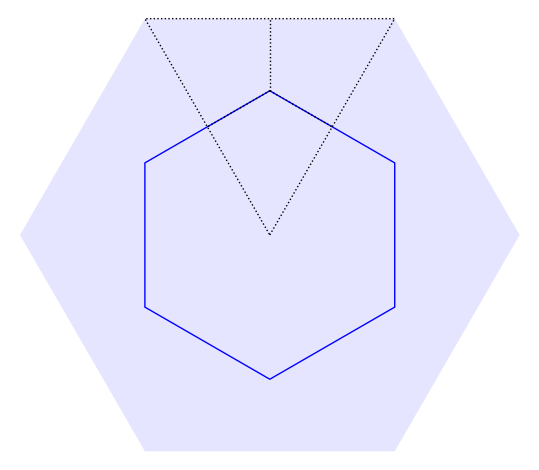

In [1]:
r1 = 1
r2 = 1/sqrt(3)
(polygon([(r1*sin(pi/6+i*pi/3),r1*cos(pi/6+i*pi/3)) for i in [0..5]],alpha=0.1,axes=false)
 +polygon([(r2*sin(i*pi/3),r2*cos(i*pi/3)) for i in [0..5]],fill=false)
 +polygon([(0,0),(r1*sin(pi/6),r1*cos(pi/6)),(r1*sin(-pi/6),r1*cos(-pi/6))],fill=false,linestyle="dotted",color="black")
 +line([(0,r2),(0,r1*cos(pi/6))],linestyle="dotted",color="black")
 +line([(0,r2),(r1/2*sin(pi/6),r1/2*cos(pi/6))],linestyle="dotted",color="black")
 +line([(0,r2),(r1/2*sin(-pi/6),r1/2*cos(-pi/6))],linestyle="dotted",color="black")
)

Extra credit
------------
Since the division is a straight line, the team starting closer to the center shovels more.

Let $r_D$ be the distance from the center of the lot to the line of division.  Given $r_D$, the greater
fraction of the lot is

In [2]:
r_D = var("r_D")
assume(r_D > 0, r_D < 1)
gf(r_D) = 1/2 + integral(sqrt(1-x^2), x, 0, r_D)*2/pi
show(gf(r_D))

(sqrt(-r_D^2 + 1)*r_D + arcsin(r_D))/pi + 1/2

The $\theta$ be the angle between the vectors from the center to the two
starting points, which is uniformly distributed between $0$ and $\pi$.

Let $r_C$ and $r_V$ be the distances from the center of the two starting
points.  The probability distributions of $r_C$ and $r_V$ are proportional
to $r_C$ and $r_V$.

Given $r_C$, $r_V$, and $\theta$, we can find the line of division, and from
the line of division, we can find $r_D$.

But first, find the probability distribution function

In [3]:
r_C, r_V, theta = var("r_C,r_V,theta")
pdf(r_C, r_V, theta) = r_C*r_V/integral(integral(integral(r_C*r_V, theta, 0, pi), r_C, 0, 1), r_V, 0, 1)
show(pdf(r_C,r_V,theta))

4*r_C*r_V/pi

Given $r_C$, $r_V$, and $\theta$, find the line of division

In [4]:
x_C = 0
y_C = r_C
x_V = r_V*sin(theta)
y_V = r_V*cos(theta)
x, y = var("x,y")
lod(x) = solve((x-x_C)^2 + (y-y_C)^2 == (x-x_V)^2 + (y-y_V)^2, y)[0].rhs().simplify_full()
show(lod(x))

-1/2*(2*r_V*x*sin(theta) + r_C^2 - r_V^2)/(r_V*cos(theta) - r_C)

And given the line of division, find its distance from the center

In [5]:
x_D = solve(derivative(x^2 + lod(x)^2, x) == 0, x)[0].rhs().simplify_full()
show(x_D)
y_D = lod(x_D).simplify_full()
show(y_D)
r_D = sqrt(x_D^2+y_D^2).simplify_full()
show(r_D)

1/2*(r_C^2*r_V - r_V^3)*sin(theta)/(2*r_C*r_V*cos(theta) - r_C^2 - r_V^2)

-1/2*(r_C^4 - r_V^4 - (r_C^2*r_V^2 - r_V^4)*sin(theta)^2 - 2*(r_C^3*r_V - r_C*r_V^3)*cos(theta))/(2*r_C*r_V^2*sin(theta)^2 - r_C^3 - 3*r_C*r_V^2 + (3*r_C^2*r_V + r_V^3)*cos(theta))

1/2*sqrt(-(r_C^4 - 2*r_C^2*r_V^2 + r_V^4)/(2*r_C*r_V*cos(theta) - r_C^2 - r_V^2))

Plugging the distance into the expression for the greater fraction and multiplying
by the probability distribution function

In [6]:
integrand(r_C,r_V,theta) = gf(r_D)*pdf(r_C,r_V,theta).simplify_full()
show(integrand)

(r_C, r_V, theta) |--> r_C*r_V*((sqrt((r_C^4 - 2*r_C^2*r_V^2 + r_V^4)/(2*r_C*r_V*cos(theta) - r_C^2 - r_V^2) + 4)*sqrt(-(r_C^4 - 2*r_C^2*r_V^2 + r_V^4)/(2*r_C*r_V*cos(theta) - r_C^2 - r_V^2)) + 4*arcsin(1/2*sqrt(-(r_C^4 - 2*r_C^2*r_V^2 + r_V^4)/(2*r_C*r_V*cos(theta) - r_C^2 - r_V^2))))/pi + 2)/pi

Evaluating the integral turns out to be difficult, so try evaluating it numerically.

In [7]:
#print(integral(integral(integral(integrand(r_C,r_V,theta),theta,0,pi),r_C,0,1),r_V,0,1))
monte_carlo_integral(integrand,[0,0,0],[1,1,pi],10000000)

(0.639796538506357, 0.00017477748875603693)

### Numerical simulations
[Numerical simulations](20260306.go) agree.

    $ go run 20260306.go
    1000,0: 0.641237
    10000,0: 0.638716
    100000,0: 0.639639
    1000000,0: 0.639707
    1000,100: 0.639968
    10000,100: 0.640088
    100000,100: 0.639794
    1000,1000: 0.639854